In [1]:
from NVAR import NVAR
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import numpy as np
from pprint import pprint

import matplotlib.pyplot as plt

from reservoirpy.nodes import NVAR as ReservoirNVAR
from reservoirpy.nodes import Ridge as ReservoirRidge


from viz.vizualisation_online_3D import live_plot_3d_trajectories

In [2]:
from scipy.integrate import solve_ivp

def lorenz(t, state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ]

t_eval = np.linspace(0, 50, 10000)
initial_state = [1.0, 1.0, 1.0]

sol = solve_ivp(
    lorenz,
    t_span=(t_eval[0], t_eval[-1]),
    y0=initial_state,
    t_eval=t_eval,
)

X = sol.y
print(X.shape)


(3, 10000)


In [3]:
def plot_3d(X, title="3D plot", label=None):
    """
    X: array-like de shape (n_points, 3) ou (3, n_points)
    """
    X = np.asarray(X)

    if X.shape[0] == 3 and X.shape[1] != 3:
        X = X.T

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError(f"Expected shape (n_points, 3) or (3, n_points), got {X.shape}")

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(X[:, 0], X[:, 1], X[:, 2], label=label)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    if label is not None:
        ax.legend()

    plt.show()


# Baseline NVAR de reservoirpy

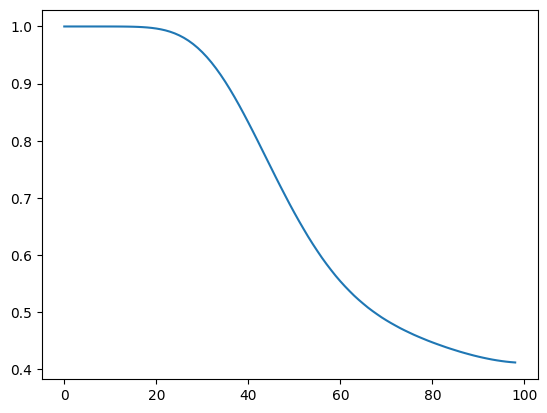

In [4]:
results_py_nvar = []
alpha=1. # coef du ridge


for tau in range(1, 100):
    # modele reservoirpy    
    X_rpy = X.T
    X_rpy_data = X_rpy[:-tau]
    y_rpy_data = X_rpy[tau:]

    split_py = int(0.7 * len(X_rpy_data))

    X_train_py = X_rpy_data[:split_py]
    y_train_py = y_rpy_data[:split_py]

    X_test_py = X_rpy_data[split_py:]
    y_test_py = y_rpy_data[split_py:]

    nvar_py = ReservoirNVAR(delay=2, order=2, strides=1)
    readout = ReservoirRidge(alpha)

    model_py = nvar_py >> readout
    model_py.fit(X_train_py, y_train_py)   

    y_pred_py = model_py.predict(X_test_py)
    r2_py = r2_score(y_test_py, y_pred_py)
    results_py_nvar.append(r2_py) 

plt.plot(results_py_nvar)

# Notre modele avec multi-scale delays

In [5]:
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True)
X_scaled = (X - X_mean) / X_std


split = int(0.7 * X_scaled.shape[1])

X_scaled_train = X_scaled[:, :split]
y_scaled_train = X_scaled[:, :split]

X_scaled_test = X_scaled[:,split:]
y_scaled_test = X_scaled[:,split:]


In [6]:
delay = 2
strides = [1, 2, 5]
order = 2
update_rate = 1.
alpha=1. # coef du ridge
tau = 1

results = []
result_per_stride_list = []


nvar = NVAR(delay, strides, order, update_rate)

nvar.fit(X_scaled_train)
states_train = nvar.transform(X_scaled_train)

min_t = nvar.valid_index
##
X_train = states_train[:-tau, :]
y_train = X_scaled_train[:, min_t + tau:].T
##

model = Ridge(alpha)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)


In [7]:
# Puis en boucle fermée sur le NVAR
nvar.reset_state()

for t in range(min_t + 1):
    x_t = X_scaled_test[:, t]
    s_t = nvar.step(x_t)


x_t = model.predict(s_t.reshape(1, -1))
pred_online = [x_t]

for _ in range(min_t + tau + 1, X_scaled_test.shape[1]):
    s_t = nvar.step(x_t.reshape(-1))
    x_t = model.predict(s_t.reshape(1, -1))

    pred_online.append(x_t)

pred_online = np.asarray(pred_online).reshape(-1, 3)
pred_online = pred_online * X_std.ravel() + X_mean.ravel()

live_plot_3d_trajectories([X, pred_online], ["Truth", "Pred"])

2026-05-01 23:34:27.892 Python[7029:21642000] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/0v/r5h9kqhj5f109d9yjt1cw7500000gn/T/org.python.python.savedState


In [8]:
strides = [1, 2, 4, 8, 16]
for i in range(len(strides)):
    print(list(strides[:1+i]))

[1]
[1, 2]
[1, 2, 4]
[1, 2, 4, 8]
[1, 2, 4, 8, 16]


[1]


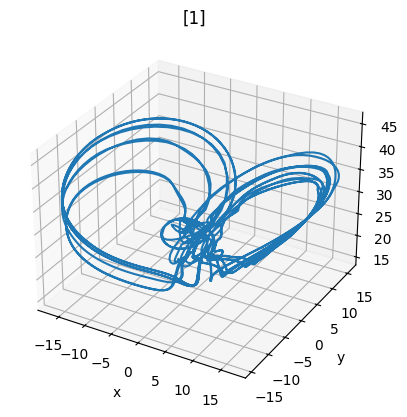

[1, 2]


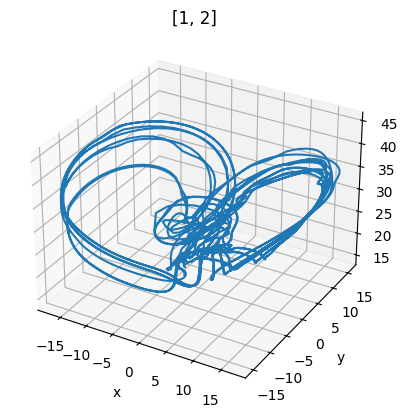

[1, 2, 4]


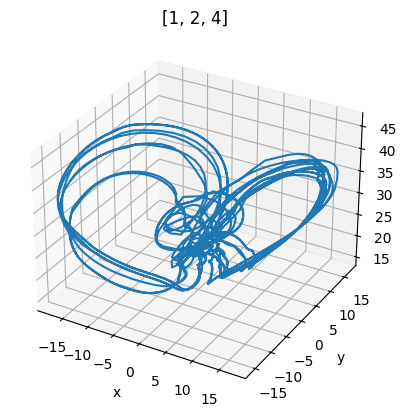

[1, 2, 4, 8]


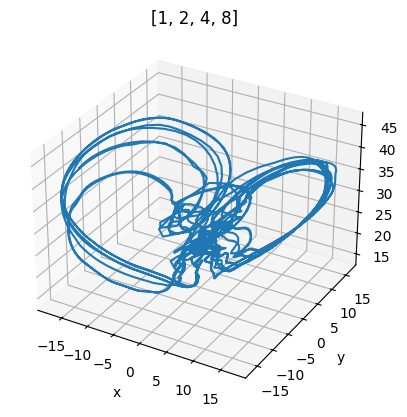

[1, 2, 4, 8, 16]


KeyboardInterrupt: 

In [9]:
delay = 2
strides = [1, 2, 4, 8, 16]
order = 2
update_rate = 1.
alpha=1. # coef du ridge


results_nvar = {}
for i in range(len(strides)):
    result_per_stride_list = []
    stride_list = strides[:1+i]
    stride_list_name = f"{stride_list}"
    print(stride_list_name)
    for tau in range(40, 41):
        # mon modele
        nvar = NVAR(delay, stride_list, order, update_rate)
        nvar.fit(X)

        states = nvar.transform(X)

        min_t = nvar.valid_index

        states_data = states[:-tau,:]
        y_data = X[:, min_t+tau:].T

        split = int(0.7 * len(states_data))
        X_tr = states_data[:split]
        y_tr = y_data[:split]

        X_te = states_data[split:]
        y_te = y_data[split:]
        
        model = Ridge(alpha)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        r2 = r2_score(y_te, y_pred)

        result_per_stride_list.append(r2)
        plot_3d(y_pred, title=stride_list_name)

    results_nvar[stride_list_name] = result_per_stride_list

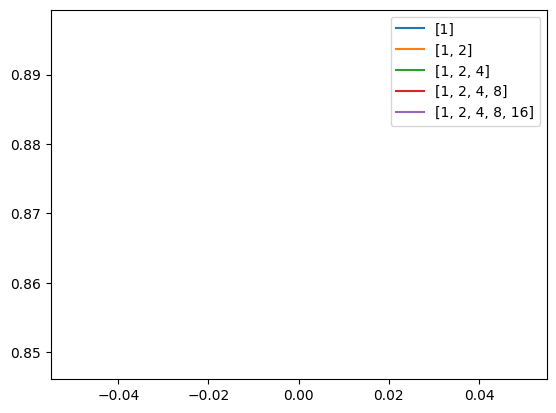

In [ ]:
for stride_list_name, results in results_nvar.items():
    plt.plot(results, label=f"{stride_list_name}")

plt.legend(loc="best")
plt.show()